:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`plot_06_sklearn_pipeline_cv_demo.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings
import jax

# Ignore the first specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Ignore the second specific warning
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

# Ignore convergence (irrelevant for this note)
# For real neural data analyis, increase solver maxiter if warning is raised.
warnings.filterwarnings(
    "ignore",
    message=(
        "The fit did not converge"
    ),
    category=RuntimeWarning,
)

jax.config.update("jax_enable_x64", True)

(sklearn-how-to)=
# Selecting basis by cross-validation with scikit-learn

In this demo, we will demonstrate how to select an appropriate basis and its hyperparameters using cross-validation.
In particular, we will learn:

1. What a scikit-learn pipeline is.
2. Why pipelines are useful.
3. How to combine NeMoS [`Basis`](nemos.basis._basis.Basis) and [`GLM`](nemos.glm.GLM) objects in a pipeline.
4. How to select the number of bases and the basis type through cross-validation (or any other hyperparameter in the pipeline).
5. How to use a custom scoring metric to quantify the performance of each configuration.



## What is a scikit-learn pipeline

<figure markdown>
<img src="../_static/pipeline.svg" style="width: 100%" alt="Pipeline illustration."/>
<figcaption>Schematic of a scikit-learn pipeline.</figcaption>
</figure>

A pipeline is a sequence of data transformations leading up to a model. Each step before the final one transforms the input data into a different representation, and then the final model step fits, predicts, or scores based on the previous step's output and some observations. Setting up such machinery can be simplified using the [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) class from scikit-learn.

To set up a scikit-learn [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), ensure that:

1. Each intermediate step is a [scikit-learn transformer object](https://scikit-learn.org/stable/data_transforms.html) with a `transform` and/or `fit_transform` method.
2. The final step is an [estimator object](https://scikit-learn.org/stable/developers/develop.html#estimators) with a `fit` method, or a model with `fit`, `predict`, and `score` methods.

Each transformation step takes a 2D array `X` of shape `(num_samples, num_original_features)` as input and outputs another 2D array of shape `(num_samples, num_transformed_features)`. The final step takes a pair `(X, y)`, where `X` is as before, and `y` is a 1D array of shape `(n_samples,)` containing the observations to be modeled.

You can define a pipeline as follows:

```{code} ipython3
from sklearn.pipeline import Pipeline

# Assume transformer_i/predictor is a transformer/model object
pipe = Pipeline(
    [
        ("label_1", transformer_1),
        ("label_2", transformer_2),
        ...,
        ("label_n", transformer_n),
        ("label_model", model)
    ]
)
```

Note that you have to assign a label to each step of the pipeline.
:::{tip}
Here we used a placeholder `"label_i"` for demonstration; you should choose a more descriptive name depending on the type of transformation step.
:::

Calling `pipe.fit(X, y)` will perform the following computations:
```{code} ipython3
# Chain of transformations
X1 = transformer_1.fit_transform(X)
X2 = transformer_2.fit_transform(X1)
# ...
Xn = transformer_n.fit_transform(Xn_1)

# Fit step
model.fit(Xn, y)
```
And the same holds for `pipe.score` and `pipe.predict`.

## Why pipelines are useful

Pipelines not only streamline and simplify your code but also offer several other advantages. The real power of pipelines becomes evident when combined with the scikit-learn [`model_selection`](https://scikit-learn.org/stable/api/sklearn.model_selection.html) module, which includes cross-validation and similar methods. This combination allows you to tune hyperparameters at each step of the pipeline in a straightforward manner.

In the following sections, we will showcase this approach with a concrete example: selecting the appropriate basis type and number of bases for a GLM regression in NeMoS.

## Combining basis transformations and GLM in a pipeline

Let's start by creating some toy data.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

import nemos as nmo

# some helper plotting functions
from nemos import _documentation_utils as doc_plots

# predictors, shape (n_samples, n_features)
X = np.random.uniform(low=0, high=1, size=(1000, 1))
# observed counts, shape (n_samples,)
rate = 2 * (
    scipy.stats.norm.pdf(X, scale=0.1, loc=0.25)
    + scipy.stats.norm.pdf(X, scale=0.1, loc=0.75)
)
y = np.random.poisson(rate).astype(float).flatten()

Let's now plot the simulated neuron's tuning curve, which is bimodal, Gaussian-shaped, and has peaks at 0.25 and 0.75.

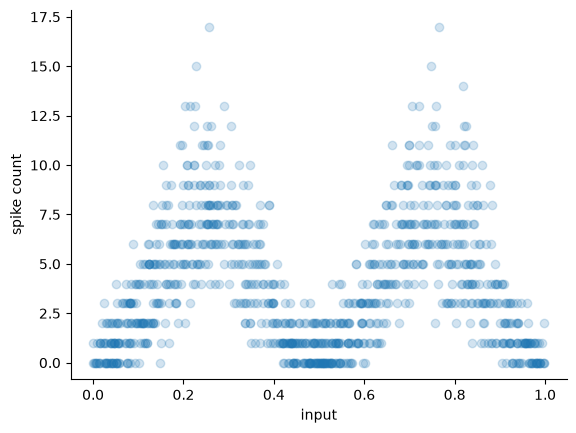

In [3]:
fig, ax = plt.subplots()
ax.scatter(X.flatten(), y, alpha=0.2)
ax.set_xlabel("input")
ax.set_ylabel("spike count")
sns.despine(ax=ax)

### Converting NeMoS `Basis` to a transformer
In order to use NeMoS [`Basis`](nemos.basis._basis.Basis) in a pipeline, we need to convert it into a scikit-learn transformer.

In [4]:
bas = nmo.basis.RaisedCosineLinearConv(5, window_size=5)

# initalize using the constructor
trans_bas = nmo.basis.TransformerBasis(bas)

# equivalent initialization via "to_transformer"
trans_bas = bas.to_transformer()


:::{admonition} Additional `TransformerBasis` Setup
:class: attention

`TransformerBasis` requires an additional setup step when working with multi-dimensional inputs. Learn everything you need to know about using `TransformerBasis` in [this note](tansformer-vs-nemos-basis).
:::

### Creating and fitting a pipeline
We might want to combine first transforming the input data with our basis functions, then fitting a GLM on the transformed data.

This is exactly what `Pipeline` is for!

:::{admonition} Setting `bounds` for cross-validation
:class: note

An `Eval` basis used as a transformer must have its `bounds` set explicitly, so that the domain stays fixed across cross-validation folds instead of being re-inferred from each fold's data. See [here for more info about bounds](transformer-basis-bounds).
:::

In [5]:
pipeline = Pipeline(
    [
        (
            "transformerbasis",
            # define bounds explicitly so the domain is consistent across folds
            nmo.basis.RaisedCosineLinearEval(6, bounds=(0, 1)).to_transformer(),
        ),
        (
            "glm",
            nmo.glm.GLM(regularizer_strength=0.5, regularizer="Ridge", solver_kwargs={"maxiter": 50}),
        ),
    ]
)

pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformerbasis', ...), ('glm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_basis_funcs,6
,bounds,"(0.0, ...)"
,width,2.0
,fill_value,nan
,label,'RaisedCosineLinearEval'
,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7fcd61c99e40>


Note how NeMoS models are already scikit-learn compatible and can be used directly in the pipeline.

Visualize the fit:

In [6]:
# Predict the rate.
# Note that you need a 2D input even if x is a flat array.
# We are using expand dim to add the extra-dimension
x = np.sort(X, axis=0)
predicted_rate = pipeline.predict(x)

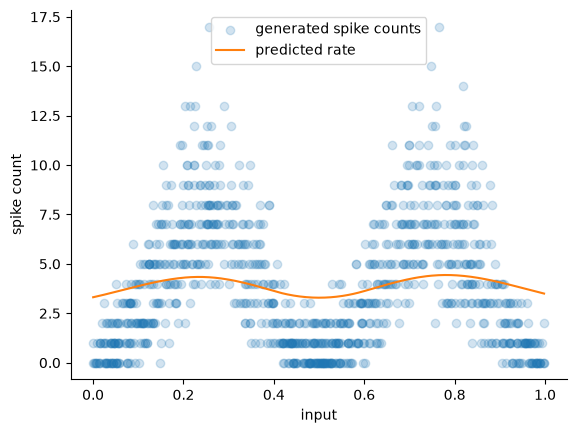

In [7]:
fig, ax = plt.subplots()

ax.scatter(X.flatten(), y, alpha=0.2, label="generated spike counts")
ax.set_xlabel("input")
ax.set_ylabel("spike count")


ax.plot(
    x,
    predicted_rate,
    label="predicted rate",
    color="tab:orange",
)

ax.legend()
sns.despine(ax=ax)

The current model captures the bimodal distribution of responses, appropriately picking out the peaks. However, it doesn't do a good job capturing the actual firing rate: the peaks are too low and the valleys are not low enough. This might be because of our choice of basis and/or regularizer strength, so let's see if tuning those parameters results in a better fit! We could do this manually, but doing this with the sklearn pipeline will make everything much easier!




### Select the number of basis by cross-validation

:::{warning}
Please keep in mind that while [`GLM.score`](nemos.glm.GLM.score) supports different ways of evaluating goodness-of-fit through the `score_type` argument, `pipeline.score(X, y, score_type="...")` does not propagate this, and uses the default value of `log-likelihood`.

To evaluate a pipeline, please create a custom scorer (e.g. `pseudo_r2` below) and call `my_custom_scorer(pipeline, X, y)`.
:::

#### Define the parameter grid

You can inspect the parameters of a transformer or that of an estimator (either a model or a pipeline object), by calling the `get_params` method.

In [8]:
pipeline["transformerbasis"].get_params()

{'basis': RaisedCosineLinearEval(n_basis_funcs=6, width=2.0, bounds=(0.0, 1.0), fill_value=nan),
 'bounds': (0.0, 1.0),
 'fill_value': nan,
 'label': 'RaisedCosineLinearEval',
 'n_basis_funcs': 6,
 'width': 2.0}

Pipelines include parameters from all the steps, as well as that of the pipeline object itself.

In [9]:
pipeline.get_params()

{'memory': None,
 'steps': [('transformerbasis',
   Transformer(RaisedCosineLinearEval(n_basis_funcs=6, width=2.0, bounds=(0.0, 1.0), fill_value=nan))),
  ('glm',
   GLM(
       observation_model=PoissonObservations(),
       inverse_link_function=exp,
       regularizer=Ridge(),
       regularizer_strength=0.5,
       fit_intercept=True,
       solver_name='Newton',
       solver_kwargs={'maxiter': 50}
   ))],
 'transform_input': None,
 'verbose': False,
 'transformerbasis': Transformer(RaisedCosineLinearEval(n_basis_funcs=6, width=2.0, bounds=(0.0, 1.0), fill_value=nan)),
 'glm': GLM(
     observation_model=PoissonObservations(),
     inverse_link_function=exp,
     regularizer=Ridge(),
     regularizer_strength=0.5,
     fit_intercept=True,
     solver_name='Newton',
     solver_kwargs={'maxiter': 50}
 ),
 'transformerbasis__basis': RaisedCosineLinearEval(n_basis_funcs=6, width=2.0, bounds=(0.0, 1.0), fill_value=nan),
 'transformerbasis__bounds': (0.0, 1.0),
 'transformerbasis__fill

You can retrieve any parameter of any pipeline step by creating a key starting with the name of the step followed by a double underscore and the name of the parameter: `step_name__parameter_name`.

In [10]:
# retrieve the number of basis function from the transformerbasis of the pipeline
pipeline.get_params()["transformerbasis__n_basis_funcs"]

6

You can set any of the parameter values with the `set_params` method, which receives the parameters as keyword arguments.

In [11]:
# set the number of basis to 8
pipeline.set_params(transformerbasis__n_basis_funcs=8)
pipeline.get_params()["transformerbasis__n_basis_funcs"]

8

Let's define candidate values for the parameters of each step of the pipeline we want to cross-validate. In this case the number of basis functions in the transformation step and the ridge regularization's strength in the GLM fit:

In [12]:
param_grid = dict(
    glm__regularizer_strength=(0.1, 0.01, 0.001, 1e-6),
    transformerbasis__n_basis_funcs=(3, 5, 10, 20, 100),
)

:::{admonition} Grid definition
:class: info
In order to define a parameter grid dictionary for a pipeline, you must structure the dictionary keys as follows:

- Start with the pipeline label (`"glm"` or `"transformerbasis"` for us). This determines which pipeline step has the relevant hyperparameter.
- Add `"__"` followed by the hyperparameter name (for example, `"n_basis_funcs"`).
- If the hyperparameter is itself an object with attributes, add another `"__"` followed by the attribute name. For instance, `"glm__regularizer__mask"`
    would be a valid key for cross-validating over the link function of the GLM's `regularizer` attribute `mask`, which is a parameter of the `GroupLasso` regularizer.
The values in the dictionary are the parameters to be tested.
:::



#### Run the grid search
Let's run a 5-fold cross-validation of the hyperparameters with the scikit-learn [`model_selection.GridsearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV) class.
:::{dropdown} K-Fold cross-validation
:color: info
:icon: info

<p align="center">
<img src="../_static/kfold.svg" alt="Grid Search Cross Validation" style="max-width: 80%; height: auto;", alt="K-fold illustration.">
<br>
<em>K-fold cross-validation (modified from <a href="https://scikit-learn.org/stable/modules/cross_validation.html" target="_blank">scikit-learn docs</a>)</em>
</p>
K-fold cross-validation is a robust method used for selecting hyperparameters. In this procedure, the data is divided into K equally sized chunks (or folds). The model is trained on K-1 of these chunks, with the remaining chunk used for evaluation. This process is repeated K times, with each chunk being used exactly once as the evaluation set.
After completing the K iterations, the K evaluation scores are averaged to provide a reliable estimate of the model's performance. To select the optimal hyperparameters, K-fold cross-validation can be applied over a grid of potential hyperparameters, with the set yielding the highest average score being chosen as the best.
:::

In [13]:
gridsearch = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5
)

# run the 5-fold cross-validation grid search
gridsearch.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...e='Newton'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'glm__regularizer_strength': (0.1, ...), 'transformerbasis__n_basis_funcs': (3, ...)}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls t

:::{dropdown} Manual cross-validation
:color: info
:icon: info
To appreciate how much boiler-plate code we are saving by calling scikit-learn cross-validation, below
we can see how this cross-validation will look like in a manual loop.

```{code} ipython
from itertools import product
from copy import deepcopy

regularizer_strength = (0.1, 0.01, 0.001, 1e-6)
n_basis_funcs = (3, 5, 10, 20, 100)

# define the folds
n_folds = 5
fold_idx = np.arange(X.shape[0] - X.shape[0] % n_folds).reshape(n_folds, -1)


# Initialize the scores
scores = np.zeros((len(regularizer_strength) * len(n_basis_funcs), n_folds))

# Dictionary to store coefficients
coeffs = {}

# initialize basis and model
basis = nmo.basis.RaisedCosineLinearEval(6, bounds=(0, 1))
basis = nmo.basis.TransformerBasis(basis)
model = nmo.glm.GLM(regularizer="Ridge")

# loop over combinations
for fold in range(n_folds):
    test_idx = fold_idx[fold]
    train_idx = fold_idx[[x for x in range(n_folds) if x != fold]].flatten()
    for i, params in enumerate(product(regularizer_strength, n_basis_funcs)):
        reg_strength, n_basis = params

        # deepcopy the basis and model
        bas = deepcopy(basis)
        glm = deepcopy(model)

        # set the parameters
        bas.n_basis_funcs = n_basis
        glm.regularizer_strength = reg_strength

        # fit the model
        glm.fit(bas.transform(X[train_idx]), y[train_idx])

        # store score and coefficients
        scores[i, fold] = glm.score(bas.transform(X[test_idx]), y[test_idx])
        coeffs[(i, fold)] = (glm.coef_, glm.intercept_)

# get the best mean test score
i_best = np.argmax(scores.mean(axis=1))
# get the overall best coeffs
fold_best = np.argmax(scores[i_best])

# set up the best model
model.coef_ = coeffs[(i_best, fold_best)][0]
model.intercept_ = coeffs[(i_best, fold_best)][1]

# get the best hyperparameters
best_reg_strength = regularizer_strength[i_best // len(n_basis_funcs)]
best_n_basis = n_basis_funcs[i_best % len(n_basis_funcs)]
```
:::



#### Visualize the scores

Let's extract the scores from `gridsearch` and take a look at how the different parameter values of our pipeline influence the test score:

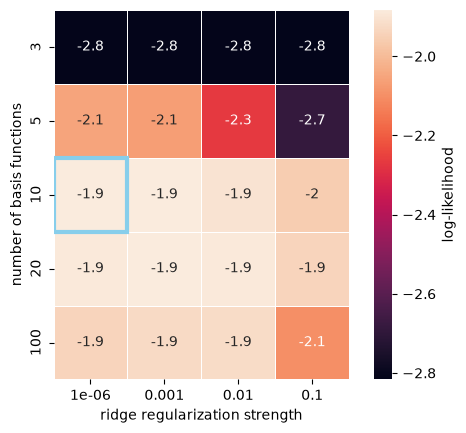

In [14]:
cvdf = pd.DataFrame(gridsearch.cv_results_)

cvdf_wide = cvdf.pivot(
    index="param_transformerbasis__n_basis_funcs",
    columns="param_glm__regularizer_strength",
    values="mean_test_score",
)

doc_plots.plot_heatmap_cv_results(cvdf_wide)

The plot displays the model's log-likelihood for each parameter combination in the grid. The parameter combination with the highest score, which is the one selected by the procedure, is highlighted with a blue rectangle. We can thus see that we need 10 or more basis functions, and that all of the tested regularization strengths agree with each other. In general, we want the fewest number of basis functions required to get a good fit, so we'll choose 10 here.

#### Visualize the predicted rate
Finally, visualize the predicted firing rates using the best model found by our grid-search, which gives a better fit than the randomly chosen parameter values we tried in the beginning:

In [15]:
# Predict the ate using the best configuration,
x = np.sort(X, axis=0)
predicted_rate = gridsearch.best_estimator_.predict(x)

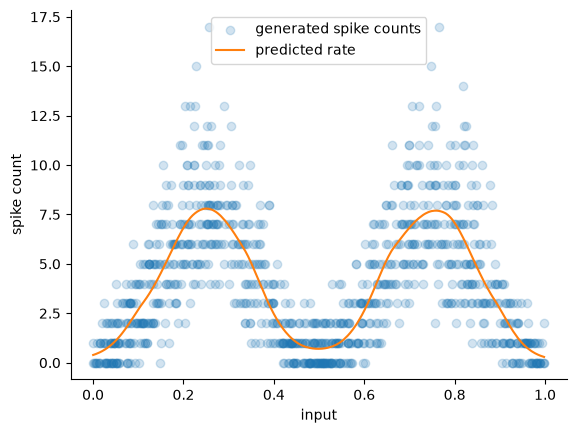

In [16]:
fig, ax = plt.subplots()

ax.scatter(X.flatten(), y, alpha=0.2, label="generated spike counts")
ax.set_xlabel("input")
ax.set_ylabel("spike count")


ax.plot(
    x,
    predicted_rate,
    label="predicted rate",
    color="tab:orange",
)

ax.legend()
sns.despine(ax=ax)

In [17]:
# save image for thumbnail
from pathlib import Path
import os

root = os.environ.get("READTHEDOCS_OUTPUT")
if root:
   path = Path(root) / "html/_static/thumbnails/how_to_guide"
# if local store in ../_build/html/...
else:
   path = Path("../_build/html/_static/thumbnails/how_to_guide")

# make sure the folder exists if run from build
if root or Path("../assets/stylesheets").exists():
   path.mkdir(parents=True, exist_ok=True)

if path.exists():
  fig.savefig(path / "plot_06_sklearn_pipeline_cv_demo.svg")

&#x1F680;&#x1F680;&#x1F680; **Success!** &#x1F680;&#x1F680;&#x1F680;

We are now able to capture the distribution of the firing rate appropriately: both peaks and valleys in the spiking activity are matched by our model predicitons.

### Evaluating different bases directly

In the previous example we set the number of basis functions of the [`Basis`](nemos.basis._basis.Basis) wrapped in our [`TransformerBasis`](nemos.basis._transformer_basis.TransformerBasis). However, if we are for example not sure about the type of basis functions we want to use, or we have already defined some basis functions of our own, then we can use cross-validation to directly evaluate those as well.

Here we include `transformerbasis__basis` in the parameter grid to try different values for `TransformerBasis.basis`:

In [18]:
param_grid = dict(
    glm__regularizer_strength=(0.1, 0.01, 0.001, 1e-6),
    transformerbasis__basis=(
        nmo.basis.RaisedCosineLinearEval(5, bounds=(0, 1)),
        nmo.basis.RaisedCosineLinearEval(10, bounds=(0, 1)),
        nmo.basis.RaisedCosineLogEval(5, bounds=(0, 1)),
        nmo.basis.RaisedCosineLogEval(10, bounds=(0, 1)),
        nmo.basis.MSplineEval(5, bounds=(0, 1)),
        nmo.basis.MSplineEval(10, bounds=(0, 1)),
    ),
)

Then run the grid search:

In [19]:
gridsearch = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
)

# run the 5-fold cross-validation grid search
gridsearch.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...e='Newton'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'glm__regularizer_strength': (0.1, ...), 'transformerbasis__basis': (RaisedCosineL...ill_value=nan), ...)}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int

Wrangling the output data a bit and looking at the scores:

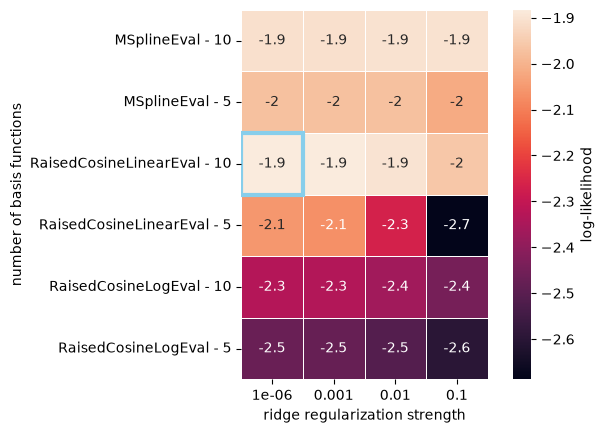

In [20]:
cvdf = pd.DataFrame(gridsearch.cv_results_)

# Read out the number of basis functions
cvdf["transformerbasis_config"] = [
    f"{b.__class__.__name__} - {b.n_basis_funcs}"
    for b in cvdf["param_transformerbasis__basis"]
]

cvdf_wide = cvdf.pivot(
    index="transformerbasis_config",
    columns="param_glm__regularizer_strength",
    values="mean_test_score",
)

doc_plots.plot_heatmap_cv_results(cvdf_wide)

As shown in the table, the model with the highest score, highlighted in blue, used a RaisedCosineLinearEval basis (as used above), which appears to be a suitable choice for our toy data.
We can confirm that by plotting the firing rate predictions:

In [21]:
# Predict the rate using the optimal configuration
x = np.sort(X, axis=0)
predicted_rate = gridsearch.best_estimator_.predict(x)

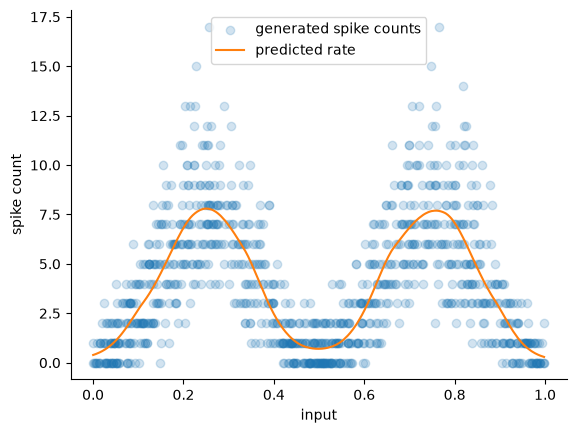

In [22]:
fig, ax = plt.subplots()

ax.scatter(X.flatten(), y, alpha=0.2, label="generated spike counts")
ax.set_xlabel("input")
ax.set_ylabel("spike count")

ax.plot(
    x,
    predicted_rate,
    label="predicted rate",
    color="tab:orange",
)

ax.legend()
sns.despine(ax=ax)

The plot confirms that the firing rate distribution is accurately captured by our model predictions.




:::{warning}
Please note that because it would lead to unexpected behavior, mixing the two ways of defining values for the parameter grid is not allowed. The following would lead to an error:


<!-- we don't want to run this, just use syntax highlighting -->

```{code} ipython

param_grid = dict(
    glm__regularizer_strength=(0.1, 0.01, 0.001, 1e-6),
    transformerbasis__n_basis_funcs=(3, 5, 10, 20, 100),
    transformerbasis__basis=(
        nmo.basis.RaisedCosineLinearEval(5),
        nmo.basis.RaisedCosineLinearEval(10),
        nmo.basis.RaisedCosineLogEval(5),
        nmo.basis.RaisedCosineLogEval(10),
        nmo.basis.MSplineEval(5),
        nmo.basis.MSplineEval(10),
    ),
)
```
:::



## Create a custom scorer
By default, the GLM score method returns the model log-likelihood. If you want to try a different metric, such as the pseudo-R2, you can create a custom scorer and pass it to the cross-validation object:

In [23]:
from sklearn.metrics import make_scorer

pseudo_r2 = make_scorer(
    nmo.observation_models.PoissonObservations().pseudo_r2
)

We can now run the grid search providing the custom scorer

In [24]:
gridsearch = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring=pseudo_r2,
)

# Run the 5-fold cross-validation grid search
gridsearch.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...e='Newton'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'glm__regularizer_strength': (0.1, ...), 'transformerbasis__basis': (RaisedCosineL...ill_value=nan), ...)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(p...hod='predict')
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

And finally, we can plot each model's score.




Plot the pseudo-R2 scores

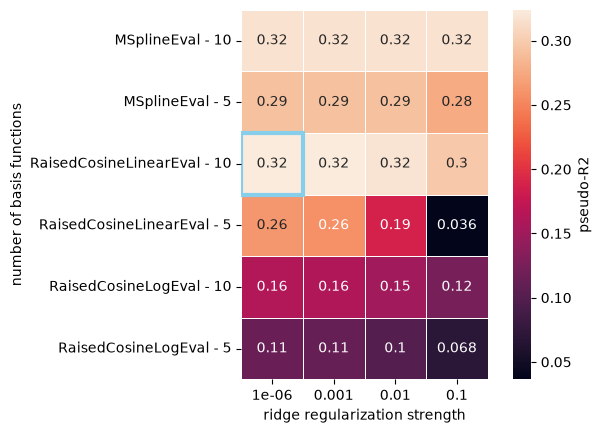

In [25]:
cvdf = pd.DataFrame(gridsearch.cv_results_)

# Read out the number of basis functions
cvdf["transformerbasis_config"] = [
    f"{b.__class__.__name__} - {b.n_basis_funcs}"
    for b in cvdf["param_transformerbasis__basis"]
]

cvdf_wide = cvdf.pivot(
    index="transformerbasis_config",
    columns="param_glm__regularizer_strength",
    values="mean_test_score",
)

doc_plots.plot_heatmap_cv_results(cvdf_wide, label="pseudo-R2")

As you can see, the results with pseudo-R2 agree with those of the negative log-likelihood. Note that this new metric is normalized between 0 and 1, with a higher score indicating better performance.